### seaborn.catplot

`catplot` is figure-level interface for drawing categorical plots onto a FaceGrid.<br/>

This function provides access to several axes-level functions that show the relationship between a numerical and one or more categorical variables using one of several visual representations. The `kind` parameter selects the underlying axes-level function to use:

Categorical scatterplots:

- `kind="strip"` (the **default**)
- `kind="swarm"`

Categorical distribution plots:

- `kind="box"`
- `kind="violin"`
- `kind="boxen"`

Categorical estimate plots:

- `kind="point"`
- `kind="bar"`
- `kind="count"`

By default, this function treats one of the variables as categorical and draws data at ordinal positions (0, 1, ...n) on the relevant axis.

<pre style="font-family:'Roboto Mono', 'Cascadia Mono Light', 'Courier New';font-size:0.85em;">
<span style="color:orange;font-weight:600;">sns</span>.<span style="color:darkblue;font-weight:600;">catplot</span>(
    data,        # dataset for plotting
    x, y, hue    # names of variables in data
    row, col     # categorical variables that determine the faceting of the grid
    kind,        # the kind of plot to draw; the name of a categorical axes-level plotting function
    estimator,   # statistical function to estimate within each categorical bin
    errorbar,    # name of errobar method ("ci","pi","se","sd") or a tuple with a method name and a level parameter
    n_boot,      # number of bootstrap samples used to compute confidence intervals
    seed,        # seed/random number generator for reproducible bootstrapping
    units,       # identifier of sampling units used by the errorbar function
    weights ,    # data values or column used to compute weighted statistics
    order,       # order to plot the categorical levels in; otherwise
    hue_order,   # the levels are inferred from the data objects.
    row_order,   # order to organize the rows and/or columns of the grid in;
    col_order,   # otherwise the orders are inferred from the data objects.
    col_wrap,    # wrap the column variable at this width, so that the column facets span multiple rows
    height,      # height of each facet (inches)
    aspect,      # aspect ratio of each facet; `aspect * height` gives the width of each facet
    native_scale # True: numeric/datetime values on the categorical axis, maintain their original scaling
    formatter,   # function for converting categorical data into strings
    orient,      # "v", "h", "x", "y": orientation of the plot (vertical or horizontal)
    color,       # single color for the elements in the plot
    palette,     # colors to use for the different levels of the <strong>hue</strong> variable
    hue_norm,    # normalization in data units for colormap applied to the hue variable
    legend,      # "auto", "brief", "full", False
    legend_out   # draws the legend outside the plot
    share{x,y}   # sharing of x/y axes
    margin_title # titles of row variable are drawn to the right of last column
    facet_kws    # dict of arguments
    kwargs       # keyword arguments
)
</pre>



### Examples

#### Default visual representation (jittered strip plot):

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [30]:
def format_axis():
    plt.grid(axis="both", c="white")
    plt.gca().set_facecolor("#EAEAF2")
    plt.gca().set_axisbelow(True)

    # Hide the lines denoting the data area boundaries.
    for _, spine in plt.gca().spines.items():
        spine.set_visible(False)

    plt.show()

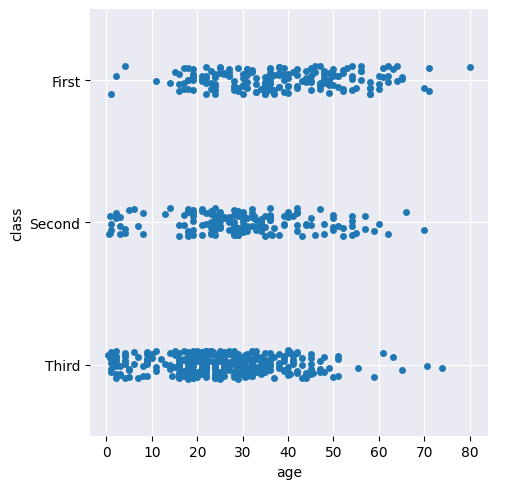

In [4]:
sns.catplot(data=df, x="age", y="class")
format_axis()

#### Use `kind` to select a different representation

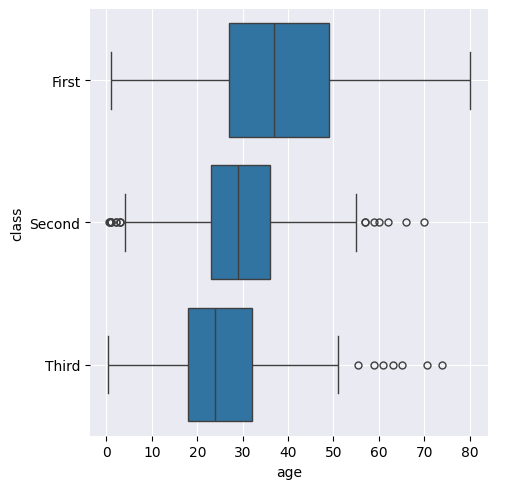

In [5]:
sns.catplot(data=df, x="age", y="class", kind="box")
format_axis()

#### Legend automatically placed outside the plot:

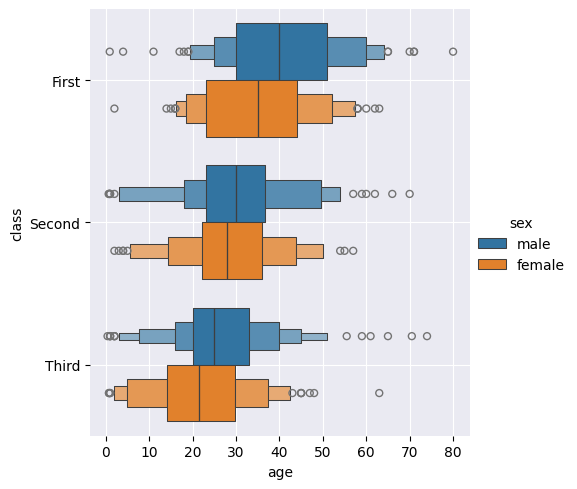

In [6]:
sns.catplot(data=df, x="age", y="class", hue="sex", kind="boxen")
format_axis()

#### Additional keyword arguments sent to underlying sns function

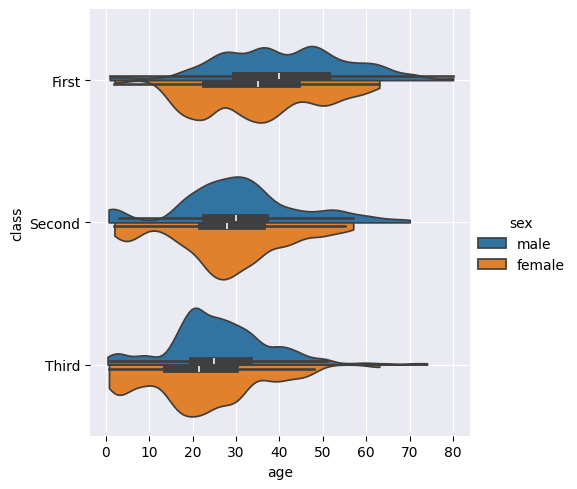

In [18]:
sns.catplot(
    data=df,
    x="age",
    y="class",
    hue="sex",
    kind="violin",
    bw_adjust=0.5,  # higher values make the curve smoother
    cut=0,  # how far the graph extends past the extreme data points
    split=True,
)
format_axis()

#### `col` and `row` attributes automatically create subplots

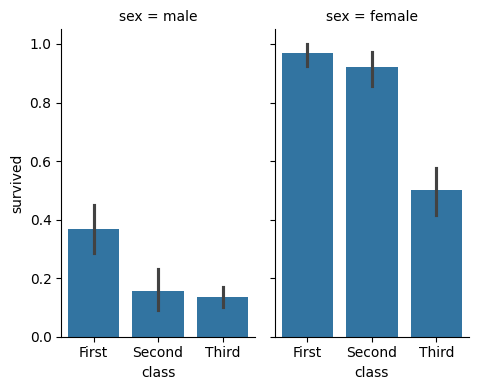

In [31]:
g = sns.catplot(
    data=df,
    x="class",
    y="survived",
    col="sex",
    kind="bar",
    height=4,
    aspect=0.6,
)

#### Layer different representations

<Axes: xlabel='age', ylabel='class'>

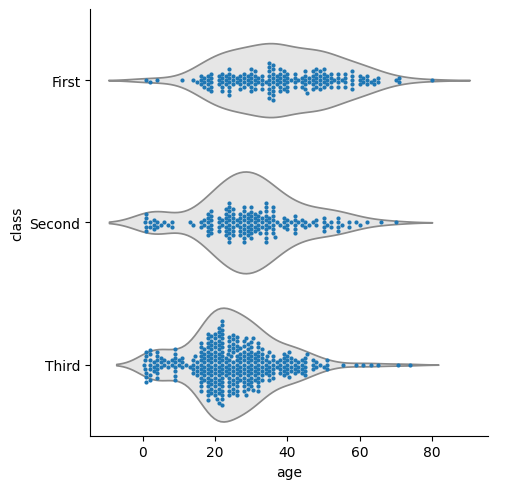

In [33]:
sns.catplot(
    data=df,
    x="age",
    y="class",
    kind="violin",
    color="0.9",
    inner=None,
)
sns.swarmplot(data=df, x="age", y="class", size=3)

#### Use methods on the returned [`FacetGrid`](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html#seaborn.FacetGrid) to tweak the presentation:

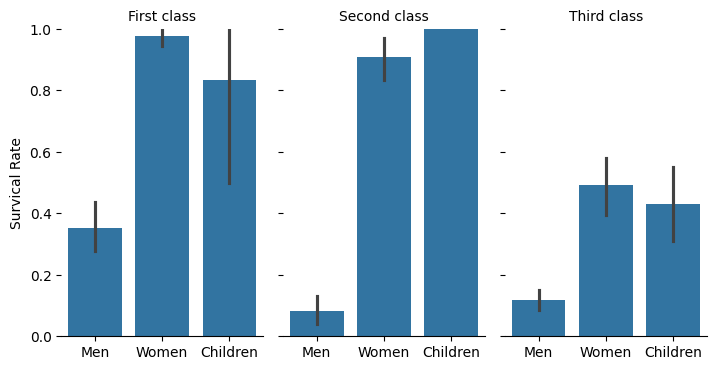

In [39]:
g = sns.catplot(
    data=df,
    x="who",
    y="survived",
    col="class",
    kind="bar",
    height=4,
    aspect=0.6,
)
g.set_axis_labels("", "Survical Rate")
g.set_xticklabels(["Men", "Women", "Children"])
g.set_titles("{col_name} {col_var}")
g.set(ylim=(0, 1))
g.despine(left=True)